# Tech Challenge - Fase 1
## Diagnóstico de Câncer de Mama com Machine Learning

Sistema de apoio ao diagnóstico focado em saúde e segurança da mulher, utilizando o
dataset **Breast Cancer Wisconsin (Diagnostic)** para classificar tumores como
**malignos** ou **benignos** a partir de características extraídas de exames de imagem
(punção aspirativa por agulha fina - FNA).

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) - Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data)
(equivalente ao dataset disponibilizado nativamente pelo `scikit-learn`, usado aqui para
garantir reprodutibilidade sem necessidade de download manual).

### Estrutura deste notebook
1. Exploração de dados
2. Pré-processamento
3. Análise de correlação
4. Modelagem (Regressão Logística, Random Forest, KNN)
5. Treinamento e avaliação (accuracy, recall, F1-score)
6. Explicabilidade (feature importance e SHAP)
7. Discussão crítica dos resultados
8. Otimização para minimizar falsos negativos
9. Guia de referência: modelos e métricas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score, fbeta_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
    average_precision_score, precision_recall_curve, matthews_corrcoef, brier_score_loss
)
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Exploração de dados

Nesta primeira etapa, o objetivo é conhecer os dados antes de qualquer modelagem:
entender quantas amostras existem, quais variáveis estão disponíveis, como elas se
distribuem e se há problemas de qualidade (valores ausentes, inconsistências). Essa
etapa é fundamental porque as decisões de pré-processamento e a escolha do modelo
dependem diretamente do que encontramos aqui.

Vamos:
- Carregar o dataset e visualizar as primeiras linhas;
- Verificar tipos de dados e valores ausentes;
- Analisar estatísticas descritivas;
- Visualizar a distribuição das classes e de algumas variáveis-chave.


In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# target: 0 = maligno, 1 = benigno (convenção do sklearn) -> renomeamos para clareza
df["diagnostico"] = df["target"].map({0: "maligno", 1: "benigno"})

print(f"Formato do dataset: {df.shape}")
df.head()


Formato do dataset: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,maligno


**O que fizemos:** carregamos o dataset com `load_breast_cancer(as_frame=True)`, que
retorna os dados já em um `DataFrame` do pandas, e criamos a coluna `diagnostico`
(texto) só para facilitar a leitura — o modelo em si usará a coluna numérica `target`
(0 = maligno, 1 = benigno).

Cada **linha** representa um exame (uma massa mamária analisada) e cada **coluna** é
uma medida numérica extraída da imagem da amostra (ex.: raio, textura, perímetro),
calculada em três variações: `mean` (média), `error` (erro padrão) e `worst`
(pior/maior valor observado no núcleo celular).

Agora vamos checar os **tipos de dados** e se há valores ausentes, para saber se algum
tratamento de limpeza será necessário.


### Dicionário de variáveis

Cada exame gera **10 medidas-base**, extraídas do contorno dos núcleos das células
observadas na imagem da amostra. Cada uma dessas 10 medidas aparece **3 vezes** no
dataset — como média (`mean`), erro padrão (`error`) e "pior caso" (`worst`) —
totalizando 10 × 3 = **30 colunas numéricas**.

| Medida-base | O que representa |
|---|---|
| `radius` (raio) | Distância média do centro do núcleo até pontos do seu contorno |
| `texture` (textura) | Desvio-padrão dos tons de cinza da imagem — indica rugosidade/variação de intensidade |
| `perimeter` (perímetro) | Comprimento do contorno do núcleo |
| `area` (área) | Área ocupada pelo núcleo |
| `smoothness` (suavidade) | Variação local no comprimento dos raios — quão irregular é o contorno em pequena escala |
| `compactness` (compacidade) | Combina forma e tamanho (perímetro² / área − 1.0) |
| `concavity` (concavidade) | Intensidade (severidade) das reentrâncias no contorno |
| `concave points` (pontos côncavos) | Número de reentrâncias no contorno |
| `symmetry` (simetria) | O quanto o formato do núcleo é simétrico |
| `fractal dimension` (dimensão fractal) | Aproximação da complexidade/irregularidade da borda do núcleo |

#### Os três grupos: `mean`, `error` e `worst`

Para cada exame, o processo de origem do dataset analisa **vários núcleos de células**
dentro da amostra (não é uma medição única) e, para cada uma das 10 medidas acima,
calcula três estatísticas resumindo essas várias observações:

| Grupo | O que é | Exemplo |
|---|---|---|
| **`mean`** | A **média** daquela medida entre todos os núcleos observados na amostra | `mean radius` = raio médio dos núcleos |
| **`error`** | O **erro padrão** (desvio-padrão da média) daquela medida entre os núcleos — mede o quão consistentes/variáveis os núcleos são entre si | `radius error` = o quanto o raio variou de núcleo para núcleo |
| **`worst`** | A **média dos três maiores valores** observados daquela medida na amostra — captura o "pior caso", a região mais extrema do tumor | `worst radius` = média dos 3 núcleos com maior raio |

**Por que isso importa clinicamente:**
- `mean` dá uma visão geral/típica do tumor;
- `error` indica heterogeneidade — quão irregular a amostra é internamente;
- `worst` foca no ponto mais extremo/suspeito da amostra — e é por isso que, como
  veremos nos boxplots e na análise de correlação, o grupo **`worst` costuma ser o mais
  discriminativo**: um único núcleo muito irregular já é um forte indício de
  malignidade, mesmo que a média geral pareça normal.

**Colunas adicionais:**
- **`target`** — rótulo numérico usado pelos modelos: `0` = maligno, `1` = benigno;
- **`diagnostico`** — mesma informação do `target`, em texto, criada só para facilitar
  a leitura nas visualizações.

De forma geral: **tumores malignos tendem a ter valores maiores** de raio, perímetro,
área e concavidade, e contornos **menos suaves/mais irregulares** — é justamente esse
padrão que os modelos vão aprender a reconhecer.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

**Por que checar isso:** o `.info()` confirma que temos 569 registros, todas as 30
features são numéricas (`float64`) e não há nenhuma coluna com valores nulos
(`Non-Null Count` = 569 em todas). Isso já indica que a etapa de limpeza de dados será
simples — não haverá necessidade de imputar valores ausentes.

Em seguida, vamos olhar as **estatísticas descritivas** (`describe()`) para entender a
escala e a dispersão de cada variável — isso importa porque variáveis em escalas muito
diferentes (ex.: `mean area` chega a milhares, enquanto `mean smoothness` fica entre 0
e 1) afetam modelos sensíveis à distância, como o KNN.


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**O que observar:** repare como `mean area` varia de 143 a 2501, enquanto
`mean smoothness` varia só entre 0.05 e 0.16 — escalas completamente diferentes. Isso
confirma que será necessário **padronizar** as variáveis antes de treinar modelos como
Regressão Logística e KNN (faremos isso na seção de pré-processamento).

Vamos agora confirmar formalmente que não há valores ausentes no dataset (checagem
programática, complementar ao que já vimos no `.info()`).


In [5]:
print("Valores ausentes por coluna:")
print(df.isna().sum().sum(), "valores ausentes no total")


Valores ausentes por coluna:
0 valores ausentes no total


Como não há valores ausentes, podemos seguir direto para entender a **distribuição da
variável-alvo** (diagnóstico) — isso é essencial porque datasets desbalanceados (uma
classe muito mais frequente que a outra) exigem cuidado extra na escolha de métricas de
avaliação, como veremos mais adiante.


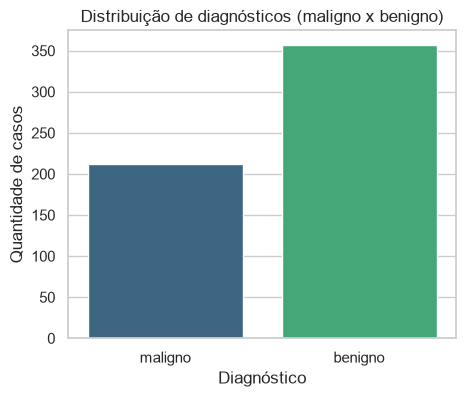

diagnostico
benigno    62.7
maligno    37.3
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="diagnostico", hue="diagnostico", palette="viridis", legend=False)
plt.title("Distribuição de diagnósticos (maligno x benigno)")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade de casos")
plt.show()

print(df["diagnostico"].value_counts(normalize=True).round(3) * 100)


**Discussão:** o dataset apresenta um desbalanceamento moderado entre as classes
(mais casos benignos do que malignos), o que reforça a necessidade de usar métricas além
da acurácia (como *recall* e *F1-score*) para avaliar o modelo, já que a classe maligna
(a que mais importa clinicamente detectar) é a minoritária.

Agora vamos comparar visualmente como algumas variáveis numéricas se comportam entre os
dois grupos (maligno x benigno), usando boxplots. O boxplot mostra a mediana, os
quartis e outliers de cada grupo — se as caixas dos dois grupos estiverem bem
separadas, é um indício de que aquela variável ajuda a distinguir as classes (bom sinal
para a modelagem).

Vamos olhar as **10 variáveis do grupo `mean`** (as médias das 10 medidas-base
apresentadas no dicionário de variáveis) — assim conseguimos ter uma visão geral de
todas as características de tamanho e forma do tumor de uma só vez.


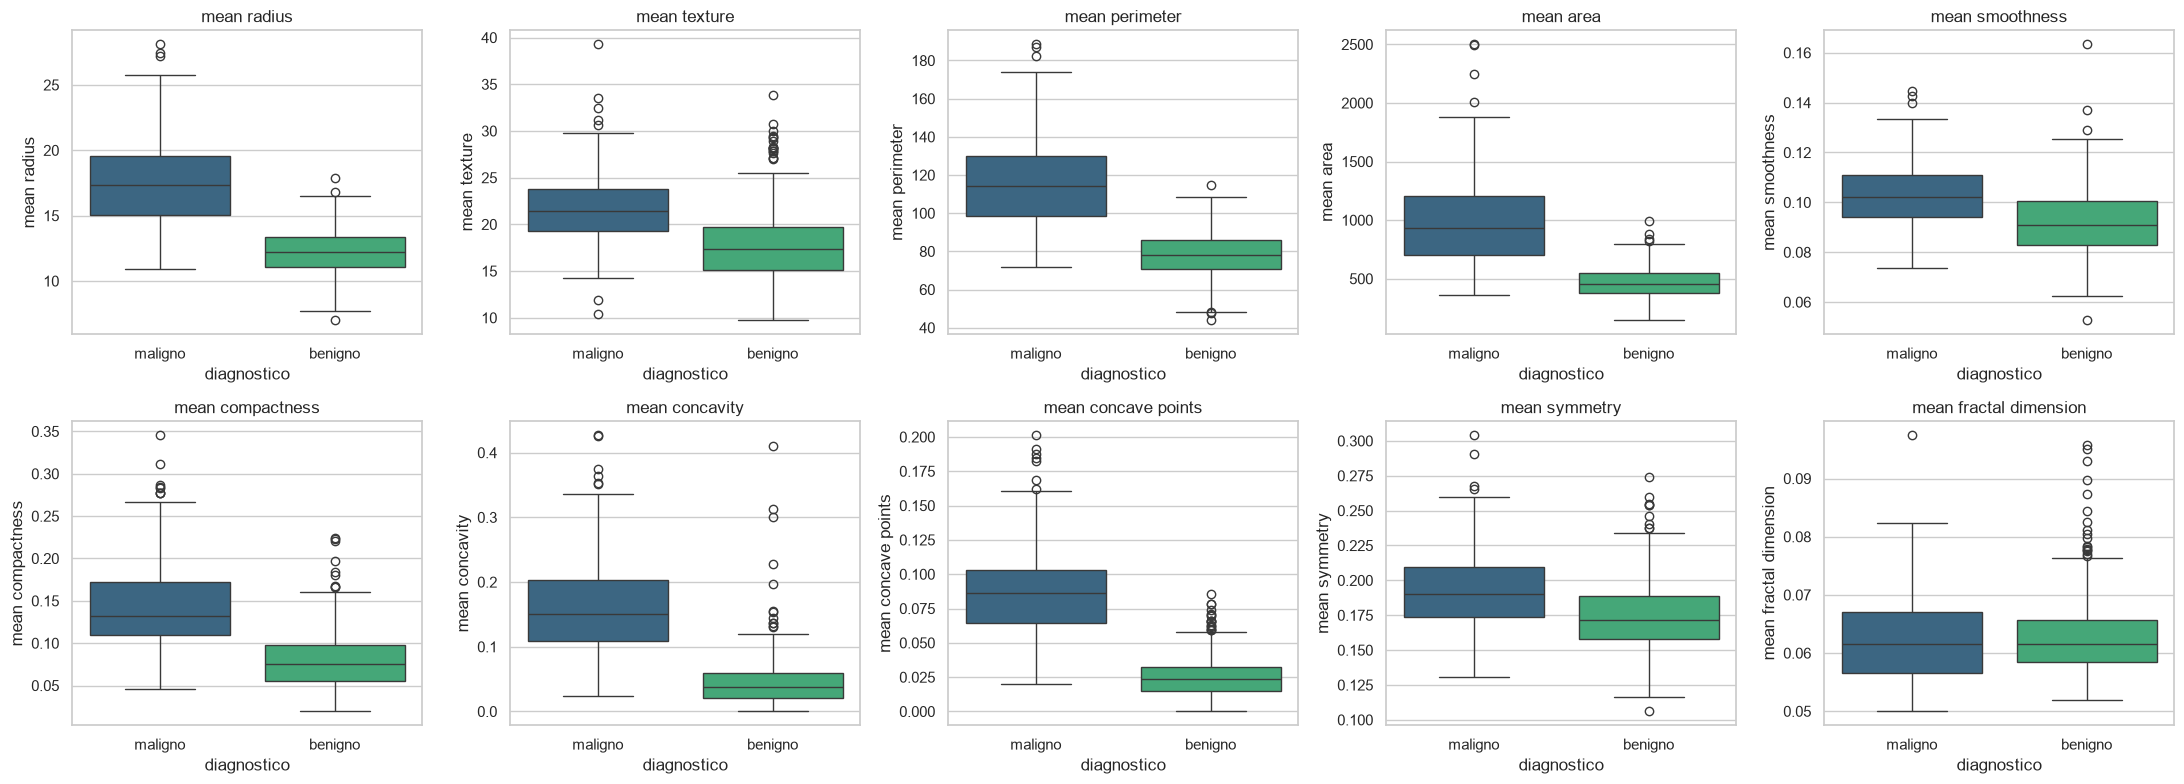

In [7]:
features_exemplo = [
    "mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness",
    "mean compactness", "mean concavity", "mean concave points", "mean symmetry", "mean fractal dimension",
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, feat in zip(axes.flat, features_exemplo):
    sns.boxplot(data=df, x="diagnostico", y=feat, hue="diagnostico", palette="viridis", legend=False, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


**Padrões observados:** tumores malignos tendem a apresentar valores maiores de
raio, perímetro, área, compacidade, concavidade e pontos côncavos em relação aos
benignos — a separação entre as caixas é bastante nítida nessas variáveis. Já em
`mean texture`, `mean smoothness`, `mean symmetry` e `mean fractal dimension` as caixas
se sobrepõem mais, sugerindo que essas variáveis têm, isoladamente, menor poder de
distinguir as duas classes. Isso é consistente com o conhecimento clínico de que
tumores malignos costumam ser maiores e ter contornos mais irregulares.

Vimos o grupo `mean`. Agora vamos repetir a mesma visualização para o grupo **`error`**
(erro padrão de cada medida entre os núcleos observados na amostra) — isso mostra se a
**variabilidade/inconsistência interna** da amostra também ajuda a distinguir malignos
de benignos, e não só os valores médios.


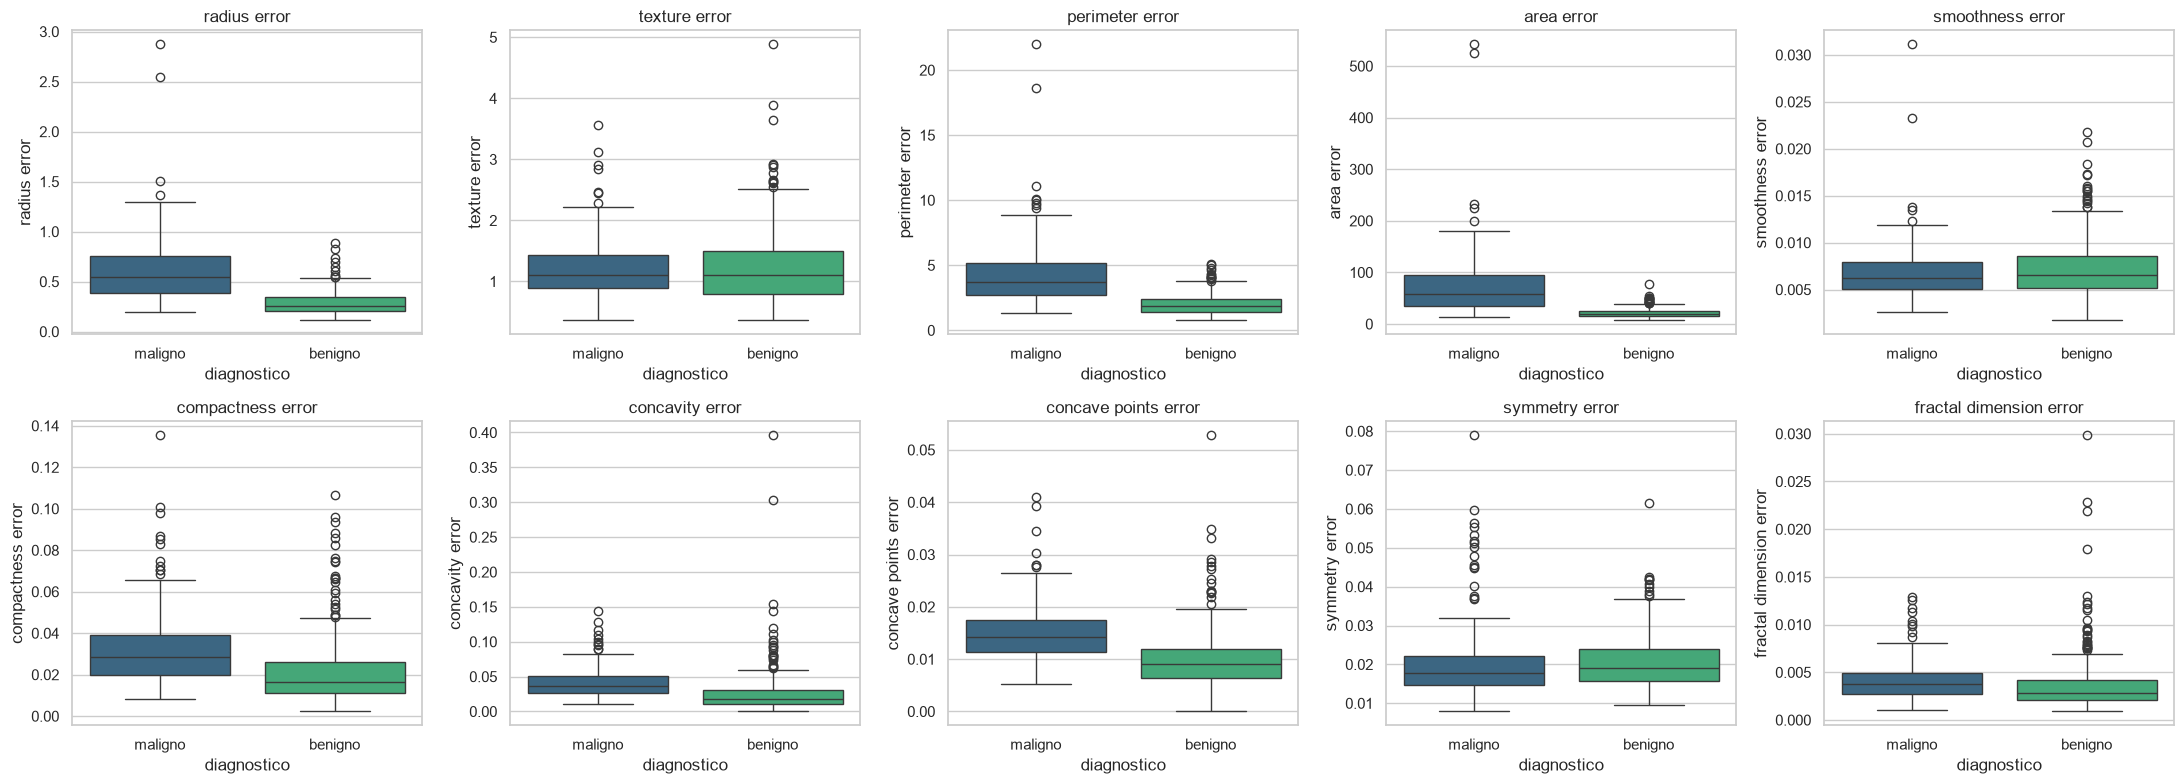

In [8]:
features_error = [
    "radius error", "texture error", "perimeter error", "area error", "smoothness error",
    "compactness error", "concavity error", "concave points error", "symmetry error", "fractal dimension error",
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, feat in zip(axes.flat, features_error):
    sns.boxplot(data=df, x="diagnostico", y=feat, hue="diagnostico", palette="viridis", legend=False, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


**Padrões observados:** `radius error`, `perimeter error` e `area error` também mostram
separação visível entre as classes — tumores malignos não são só maiores, como também
têm **maior variabilidade** nessas medidas entre os núcleos. Já `texture error`,
`smoothness error`, `symmetry error` e `fractal dimension error` têm caixas quase
totalmente sobrepostas, indicando pouco poder discriminativo isoladamente — de forma
geral, o grupo `error` como um todo discrimina menos do que o grupo `mean`.

Agora vamos ao grupo **`worst`** (média dos três maiores valores observados na
amostra) — como vimos na análise de correlação, é o grupo com as variáveis
individualmente mais discriminativas de todo o dataset.


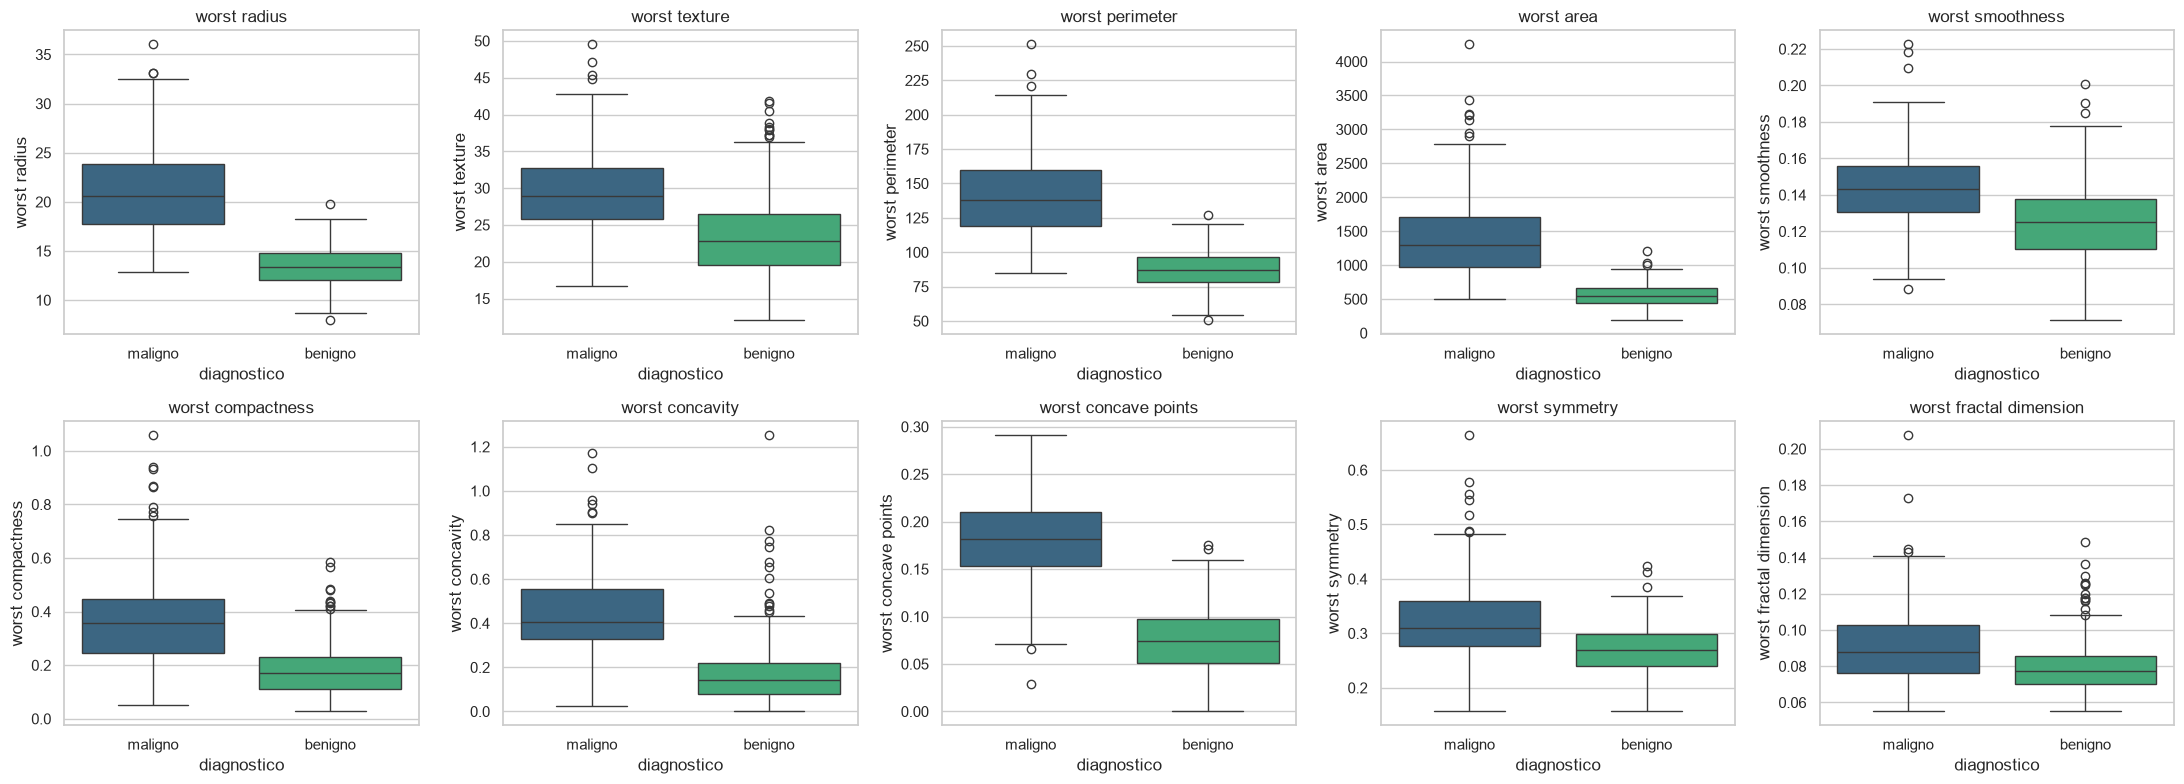

In [9]:
features_worst = [
    "worst radius", "worst texture", "worst perimeter", "worst area", "worst smoothness",
    "worst compactness", "worst concavity", "worst concave points", "worst symmetry", "worst fractal dimension",
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, feat in zip(axes.flat, features_worst):
    sns.boxplot(data=df, x="diagnostico", y=feat, hue="diagnostico", palette="viridis", legend=False, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


**Padrões observados:** o grupo `worst` mostra a separação mais nítida entre as três
categorias — em `worst concave points`, `worst perimeter`, `worst radius` e
`worst area` as caixas de maligno e benigno praticamente não se sobrepõem. Isso é
coerente com a análise de correlação (seção 3): esse é o grupo com maior poder
discriminativo, pois captura o "pior" ponto observado no tumor — a região mais
irregular tende a ser a mais reveladora de malignidade.

**Resumindo os três grupos:** `worst` > `mean` > `error` em poder discriminativo
visual. Isso faz sentido clinicamente: o valor médio e, principalmente, o "pior caso"
de irregularidade do núcleo são mais informativos do que a variabilidade interna da
amostra (`error`).


## 2. Pré-processamento de dados

Antes de treinar qualquer modelo, precisamos organizar os dados no formato que o
scikit-learn espera:

- **X** (variáveis preditoras): todas as colunas numéricas que o modelo usará para
  "aprender" o padrão;
- **y** (variável-alvo): a coluna que queremos prever — neste caso, `target`
  (0 = maligno, 1 = benigno).

Não há variáveis categóricas neste dataset (todas já são numéricas), então não
precisamos de codificação (ex.: one-hot encoding).


In [10]:
# Não há valores ausentes ou inconsistentes neste dataset (já verificado acima).
# Separação entre variáveis preditoras (X) e variável alvo (y)
X = df[data.feature_names]
y = df["target"]  # 0 = maligno, 1 = benigno

# Todas as variáveis já são numéricas (não há variáveis categóricas a codificar)
print(X.dtypes.unique())


[dtype('float64')]


**Separação treino/teste:** dividimos os dados em duas partes — uma para o modelo
**aprender** (treino) e outra que ele **nunca viu** durante o treinamento, usada só
para avaliar o desempenho de forma honesta (teste). Usamos `test_size=0.2` (20% para
teste) e `stratify=y` para garantir que a proporção de malignos/benignos seja a mesma
nos dois conjuntos — sem isso, poderíamos ter, por azar, poucos casos malignos no
teste, distorcendo a avaliação.

**Padronização (`StandardScaler`):** transforma cada variável para ter média 0 e
desvio padrão 1. É importante porque, como vimos no `describe()`, as variáveis têm
escalas muito diferentes — sem padronização, variáveis com valores maiores (como
`area`) dominariam o cálculo de distância no KNN e teriam peso artificialmente maior na
Regressão Logística. O `scaler` é ajustado (`fit_transform`) **apenas com os dados de
treino**, e depois aplicado (`transform`) no teste — isso evita "vazamento de
informação" do conjunto de teste para o treino.


In [11]:
# Dividimos em treino (80%) e teste (20%), mantendo a mesma proporção de classes
# (stratify=y) em ambos os conjuntos, para uma avaliação justa.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Padronização: média 0 e desvio padrão 1 em cada variável.
# fit_transform() no treino (aprende média/desvio); transform() no teste
# (aplica os mesmos parâmetros aprendidos, sem "espiar" o teste).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")


Treino: 455 amostras | Teste: 114 amostras


**Pipeline de pré-processamento:**
1. Verificação de valores ausentes/inconsistentes (nenhum encontrado);
2. Separação treino/teste com estratificação para preservar a proporção de classes;
3. Padronização (`StandardScaler`) das variáveis numéricas, importante para modelos
   sensíveis à escala como Regressão Logística e KNN.

## 3. Análise de correlação

A matriz de correlação mede o quanto cada par de variáveis se move junto (de -1 a +1).
Valores próximos de +1 ou -1 indicam forte relação linear; valores próximos de 0
indicam pouca relação. Isso ajuda a identificar **redundância** entre variáveis (ex.:
`radius`, `perimeter` e `area` tendem a ser altamente correlacionadas entre si, pois
medem aspectos parecidos do tamanho do tumor) e a entender quais variáveis têm mais
relação com o diagnóstico.


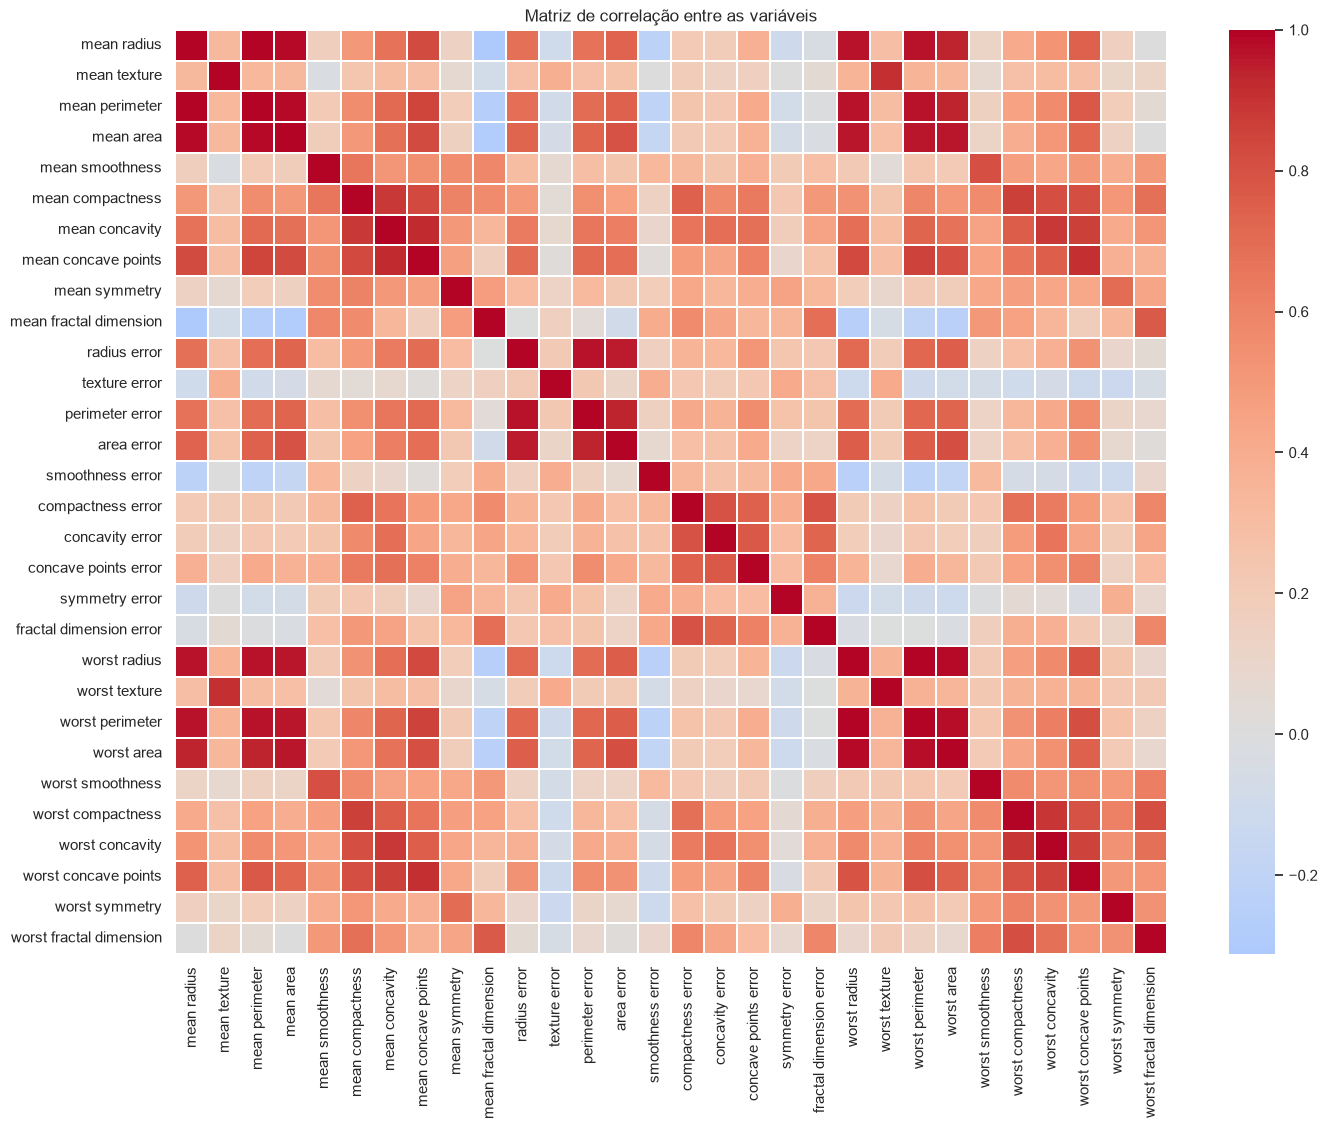

In [12]:
plt.figure(figsize=(16, 12))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Matriz de correlação entre as variáveis")
plt.show()


O heatmap mostra a correlação entre **todas** as variáveis entre si. Agora vamos focar
especificamente em quais variáveis são mais correlacionadas com o **diagnóstico**
(`target`) — essas são candidatas fortes a serem as mais importantes para o modelo
prever corretamente a classe.


In [13]:
corr_com_target = df[list(data.feature_names) + ["target"]].corr()["target"].drop("target").sort_values()
print("Variáveis mais correlacionadas com o diagnóstico (target):")
print(corr_com_target.head(5))
print("...")
print(corr_com_target.tail(5))


Variáveis mais correlacionadas com o diagnóstico (target):
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
Name: target, dtype: float64
...
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0.008303
mean fractal dimension     0.012838
smoothness error           0.067016
Name: target, dtype: float64


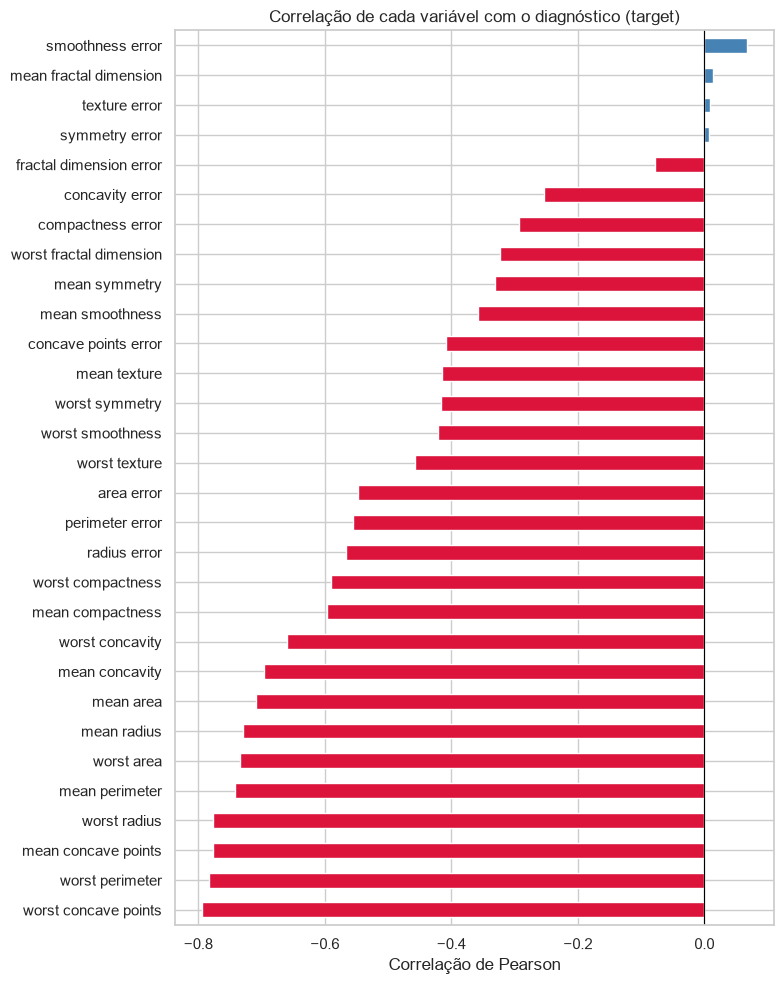

In [14]:
# Gráfico de barras horizontais com a correlação de TODAS as 30 variáveis com o
# diagnóstico, na mesma ordem calculada acima (do mais negativo ao mais positivo)
cores = ["crimson" if v < 0 else "steelblue" for v in corr_com_target]

plt.figure(figsize=(8, 10))
corr_com_target.plot(kind="barh", color=cores)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlação de cada variável com o diagnóstico (target)")
plt.xlabel("Correlação de Pearson")
plt.tight_layout()
plt.show()


**Discussão:** há forte correlação entre variáveis relacionadas ao tamanho do tumor
(raio, perímetro, área) — o que é esperado, já que são medidas derivadas umas das
outras. Variáveis como `worst concave points`, `worst perimeter` e `mean concave points`
apresentam a maior correlação (negativa, pois target=0 é maligno) com o diagnóstico,
sugerindo forte poder discriminativo.

O gráfico acima deixa isso visível de uma vez para as 30 variáveis: barras mais longas
(para qualquer um dos lados) indicam maior correlação com o diagnóstico; a linha
vertical em 0 marca ausência de correlação. Note como a maioria das barras é negativa
— um lembrete de que, na codificação do sklearn, `target=0` é maligno, então valores
altos dessas variáveis "puxam" a correlação para negativo, mas na prática significam
maior chance de malignidade.

## 4. Modelagem

### Por que escolher justamente esses três modelos?

O desafio pede pelo menos duas técnicas de classificação para comparação. Escolhemos
**três**, priorizando critérios importantes para um contexto médico, e não só a
métrica de desempenho:

1. **Diversidade de abordagem** — um modelo linear (Regressão Logística), um baseado
   em ensemble de árvores (Random Forest) e um baseado em distância/similaridade
   (KNN). Cada família de algoritmo captura padrões diferentes nos dados; comparar os
   três reduz o risco de "apostar" na abordagem errada;
2. **Interpretabilidade** — em diagnóstico médico, um modelo "caixa-preta" que acerta
   mas não explica o porquê é menos útil na prática do que um modelo um pouco menos
   preciso, mas que o profissional de saúde consegue auditar. Os três escolhidos são
   relativamente fáceis de interpretar (pesos, importância de variáveis, vizinhos), o
   que também viabiliza a análise de explicabilidade da seção 6;
3. **Adequação ao tamanho do dataset** — com apenas 569 amostras, modelos mais simples
   tendem a generalizar melhor do que modelos muito complexos (que exigem mais dados
   para não sofrer overfitting);
4. **Baseline estabelecido na literatura** — esses três algoritmos (ou variações
   próximas) são amplamente usados como ponto de partida em problemas de
   classificação binária tabular, o que facilita comparar nossos resultados com
   outros trabalhos sobre este mesmo dataset.

- **Regressão Logística:** modelo linear que estima a probabilidade de um exame ser
  maligno combinando as variáveis com pesos aprendidos. É simples, rápido e fácil de
  interpretar (cada peso indica o quanto aquela variável "empurra" a previsão para
  maligno ou benigno).
- **Random Forest:** ensemble de várias árvores de decisão treinadas em subamostras
  diferentes dos dados, cuja previsão final é a média/voto das árvores individuais.
  Reduz o overfitting e a variância de uma árvore única, mantendo boa
  interpretabilidade via `feature_importances_`. Foi escolhido no lugar de uma única
  Árvore de Decisão depois de testes empíricos (seção 8) mostrarem que uma árvore
  isolada gera probabilidades "grosseiras" (poucos valores possíveis por folha), o que
  a torna estruturalmente inadequada para o ajuste de limiar necessário para minimizar
  falsos negativos — o Random Forest, por ser uma média de várias árvores, produz
  probabilidades muito mais contínuas e não sofre dessa limitação;
- **KNN (K-Nearest Neighbors):** classifica um novo exame olhando para os `k` exames
  mais parecidos (mais próximos, em distância) no conjunto de treino e usando a classe
  mais comum entre eles (aqui, ponderada pela distância — vizinhos mais próximos pesam
  mais). Não "aprende" um modelo explícito — a decisão é feita comparando com casos
  conhecidos, por isso é sensível à escala das variáveis (daí a importância da
  padronização feita antes). Usamos `k=15` (em vez de um valor menor, como 5): mais
  vizinhos e a ponderação por distância dão probabilidades mais granulares, o que
  também favorece o ajuste de limiar da seção 8, além de melhorar ligeiramente a
  accuracy em relação a um `k` menor.

#### Outros modelos que poderiam ser utilizados

| Modelo | Por que é uma opção válida | Por que não foi a escolha principal aqui |
|---|---|---|
| **SVM (Support Vector Machine)** | Costuma ter ótimo desempenho em datasets pequenos/médios com muitas features, como este; encontra a fronteira de separação com maior margem entre as classes | Menos intuitivo de explicar a um público não-técnico do que os três escolhidos, especialmente com kernels não-lineares |
| **Árvore de Decisão (única)** | Fácil de visualizar como uma sequência de perguntas "se-então"; boa para explicar a lógica de uma única decisão | Testamos empiricamente (seção 8) e uma árvore isolada tem probabilidades muito discretas (poucas folhas), o que a impede de fazer um ajuste de limiar eficaz para eliminar falsos negativos sem degenerar o modelo — o Random Forest resolve essa limitação |
| **Gradient Boosting (XGBoost/LightGBM)** | Estado da arte em muitos problemas tabulares, geralmente supera os modelos mais simples em métricas puras | Mais propenso a overfitting em datasets pequenos sem tuning cuidadoso; menos direto de explicar; dependência externa (não vem no scikit-learn básico) |
| **Naive Bayes** | Muito rápido, funciona bem mesmo com poucos dados, bom baseline probabilístico | Assume que as variáveis são independentes entre si — o que sabemos ser falso aqui (vimos forte correlação entre `radius`, `perimeter` e `area` na seção 3), o que tende a prejudicar sua precisão |
| **Redes Neurais (MLP)** | Capaz de capturar padrões complexos e não-lineares | Exige mais dados para generalizar bem, é a menos interpretável de todas, e é "canhão para matar mosquito" em um dataset de 569 linhas e 30 colunas |

**Em resumo:** a escolha não foi "qual modelo tem o número mais alto", mas sim um
equilíbrio entre desempenho, interpretabilidade e adequação ao tamanho do dataset —
características especialmente relevantes em um sistema de apoio à decisão médica. A
configuração destes três modelos (Random Forest no lugar de uma árvore única, KNN com
`k=15` em vez de `k=5`) foi revisada depois de uma comparação empírica entre 8
algoritmos, especificamente para viabilizar o objetivo de **minimizar falsos
negativos** explorado na seção 8. Nada impede que, em uma fase futura, SVM ou
Gradient Boosting sejam testados e comparados com os resultados obtidos aqui.

In [15]:
modelos = {
    # Modelo linear e interpretável; max_iter alto para garantir convergência
    "Regressão Logística": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    # Ensemble de árvores: mais robusto que uma árvore única e com probabilidades mais
    # contínuas, importante para o ajuste de limiar da seção 8
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    # k=15 com peso por distância: probabilidades mais granulares que k=5 (viabiliza o
    # ajuste de limiar da seção 8) e leve ganho de accuracy
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance"),
}

## 5. Treinamento e avaliação do modelo

Para cada modelo, o processo é sempre o mesmo:
1. `fit()` — o modelo "aprende" os padrões usando os dados de **treino** (já
   padronizados);
2. `predict()` — o modelo faz previsões sobre os dados de **teste** (que ele nunca
   viu);
3. Comparamos as previsões com os rótulos reais do teste para calcular as métricas de
   desempenho.

**O que cada métrica significa:**
- **Accuracy:** % de previsões corretas no total — pode enganar em datasets
  desbalanceados;
- **Precision:** das vezes que o modelo previu uma classe, quantas realmente eram
  daquela classe (mede falsos positivos);
- **Recall:** dos casos que realmente pertenciam a uma classe, quantos o modelo
  conseguiu identificar corretamente (mede falsos negativos) — **a métrica mais
  importante aqui para a classe maligna**, pois um falso negativo em câncer é o erro
  mais grave;
- **F1-score:** média harmônica entre precision e recall — resume os dois em um único
  número;
- **ROC-AUC:** mede a capacidade do modelo de separar as duas classes considerando
  todas as possíveis probabilidades de corte (quanto mais perto de 1, melhor).


In [16]:
resultados = []

# Para cada modelo: treina (fit), prediz no conjunto de teste (predict)
# e calcula as métricas de avaliação a partir das previsões.
# IMPORTANTE: por padrão, precision_score/recall_score/f1_score do scikit-learn
# calculam a métrica para o rótulo 1 (aqui, benigno). Como a classe clinicamente
# prioritária é a maligna (rótulo 0), especificamos pos_label=0 explicitamente para
# que os números reflitam de fato o que o texto abaixo discute.
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    proba_maligno = modelo.predict_proba(X_test_scaled)[:, 0]  # coluna 0 = P(maligno)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (maligno)": precision_score(y_test, y_pred, pos_label=0),
        "Recall (maligno)": recall_score(y_test, y_pred, pos_label=0),
        "Specificity (benigno)": recall_score(y_test, y_pred, pos_label=1),
        "F1 (maligno)": f1_score(y_test, y_pred, pos_label=0),
        "F2 (maligno)": fbeta_score(y_test, y_pred, beta=2, pos_label=0),
        "PR-AUC (maligno)": average_precision_score(y_test, proba_maligno, pos_label=0),
        "ROC-AUC": roc_auc_score(y_test, modelo.predict_proba(X_test_scaled)[:, 1]),
        "MCC": matthews_corrcoef(y_test, y_pred),
    })

df_resultados = pd.DataFrame(resultados).set_index("Modelo").round(4)
df_resultados

,Accuracy,Precision (maligno),Recall (maligno),Specificity (benigno),F1 (maligno),F2 (maligno),PR-AUC (maligno),ROC-AUC,MCC
Modelo,,,,,,,,,
Regressão Logística,0.9825,0.9762,0.9762,0.9861,0.9762,0.9762,0.9940,0.9954,0.9623
Random Forest,0.9561,0.9512,0.9286,0.9722,0.9398,0.9330,0.9900,0.9939,0.9054
KNN,0.9737,1.0000,0.9286,1.0000,0.9630,0.9420,0.9898,0.9927,0.9442


**Nota de correção:** por padrão, `precision_score`, `recall_score` e `f1_score` do
scikit-learn calculam a métrica para o rótulo `1` — aqui, **benigno** — e não para o
`0` (**maligno**), que é a classe clinicamente mais importante. Na versão anterior
deste notebook, a tabela acima computava essas três colunas sem especificar isso, ou
seja, media benigno em vez de maligno. Corrigimos com `pos_label=0` e renomeamos as
colunas para deixar isso explícito.

Também adicionamos quatro métricas complementares:
- **F2-score:** como o F1-score, mas dá **peso maior ao recall** do que à precisão —
  penaliza mais fortemente os falsos negativos;
- **PR-AUC (average precision):** resume a curva precision-recall da classe maligna;
  mais informativa que o ROC-AUC quando as classes são desbalanceadas e o custo dos
  erros é assimétrico (como aqui);
- **Specificity (benigno):** o recall da classe benigna (`pos_label=1`) — o par
  clássico do recall/sensibilidade na literatura médica, e a métrica que quantifica
  diretamente o "custo" de qualquer ajuste que priorize recall do maligno (quantos
  benignos passam a ser sinalizados à toa);
- **MCC (Matthews Correlation Coefficient):** usa as quatro células da matriz de
  confusão (incluindo verdadeiros negativos, que o F1 ignora), sendo considerado mais
  robusto que accuracy/F1 sob desbalanceamento de classes — funciona como um "resumo"
  único e mais confiável da qualidade geral do classificador.

A tabela acima resume o desempenho geral, mas para entender **onde** cada modelo erra,
usamos a matriz de confusão. Ela cruza o que o modelo previu com o que era o rótulo
real, em 4 quadrantes:

- **Verdadeiro Positivo / Negativo:** o modelo acertou;
- **Falso Positivo:** o modelo previu uma classe que não era a real;
- **Falso Negativo:** o modelo deixou passar um caso da classe real — é o quadrante
  mais crítico quando a classe real é "maligno", pois representa um diagnóstico
  perdido.


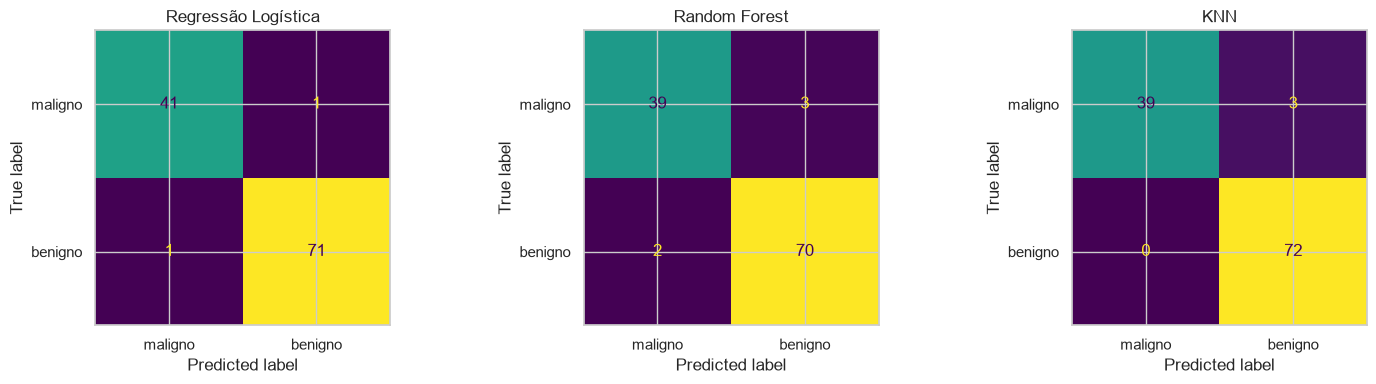

In [17]:
fig, axes = plt.subplots(1, len(modelos), figsize=(15, 4))
for ax, (nome, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["maligno", "benigno"]).plot(ax=ax, colorbar=False)
    ax.set_title(nome)
plt.tight_layout()
plt.show()


A matriz de confusão mostra os números brutos; o `classification_report` traduz isso em
**precision, recall e F1-score separados por classe** (maligno e benigno), além do
`support` (quantos exemplos de cada classe existem no teste). Isso é importante porque
o desempenho pode ser bom para uma classe e ruim para outra — olhar só a métrica
"geral" (média) pode esconder isso.


In [18]:
for nome, modelo in modelos.items():
    print(f"\n=== {nome} ===")
    y_pred = modelo.predict(X_test_scaled)
    print(classification_report(y_test, y_pred, target_names=["maligno", "benigno"]))



=== Regressão Logística ===
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== Random Forest ===
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


=== KNN ===
              precision    recall  f1-score   support

     maligno       1.00      0.93      0.96        42
     benigno       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted 

**Escolha da métrica:** em um cenário de diagnóstico médico, um **falso negativo**
(dizer que um tumor maligno é benigno) é muito mais grave do que um falso positivo,
pois pode atrasar um tratamento necessário. Por isso, o **recall da classe maligna**
é a métrica mais importante a ser priorizada, junto com o **F1-score**, que equilibra
precisão e recall. A acurácia isolada pode ser enganosa devido ao desbalanceamento
das classes.

## 6. Explicabilidade do modelo

Depois de treinar e avaliar os modelos, é importante entender **por que** eles chegam
às previsões que chegam — isso é chamado de **explicabilidade**, e é especialmente
importante em contextos médicos, onde o profissional de saúde precisa confiar (e
entender) o motivo por trás de uma sugestão do modelo.

Começamos pelo **Random Forest**, que tem uma medida nativa chamada
`feature_importances_`: indica o quanto cada variável contribuiu, em média, para
reduzir a "incerteza" nas divisões das árvores que compõem o modelo. Quanto maior o
valor, mais aquela variável foi usada para separar malignos de benignos.

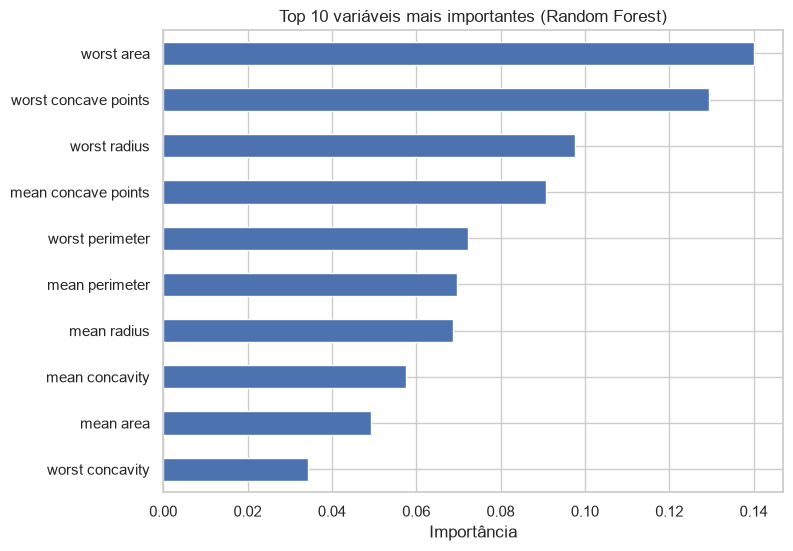

In [19]:
# Feature importance - Random Forest
random_forest = modelos["Random Forest"]
importancias = pd.Series(random_forest.feature_importances_, index=data.feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancias.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 variáveis mais importantes (Random Forest)")
plt.xlabel("Importância")
plt.show()

A importância de features do Random Forest mostra **quais** variáveis importam, mas
não **como** (se valores altos daquela variável aumentam ou diminuem a chance de
malignidade). Para isso, usamos **SHAP** (SHapley Additive exPlanations) na Regressão
Logística — uma técnica que calcula, para cada previsão individual, o quanto cada
variável contribuiu para "empurrar" o resultado para maligno ou benigno.

No gráfico (`summary_plot`), cada ponto é um exame do conjunto de teste: a posição no
eixo horizontal mostra o impacto daquela variável na previsão (direita = empurra para
uma classe, esquerda = para outra) e a cor mostra se o valor da variável era alto
(vermelho) ou baixo (azul) naquele exame. Isso permite ver, por exemplo, se valores
altos de `worst concave points` consistentemente aumentam a chance prevista de
malignidade.

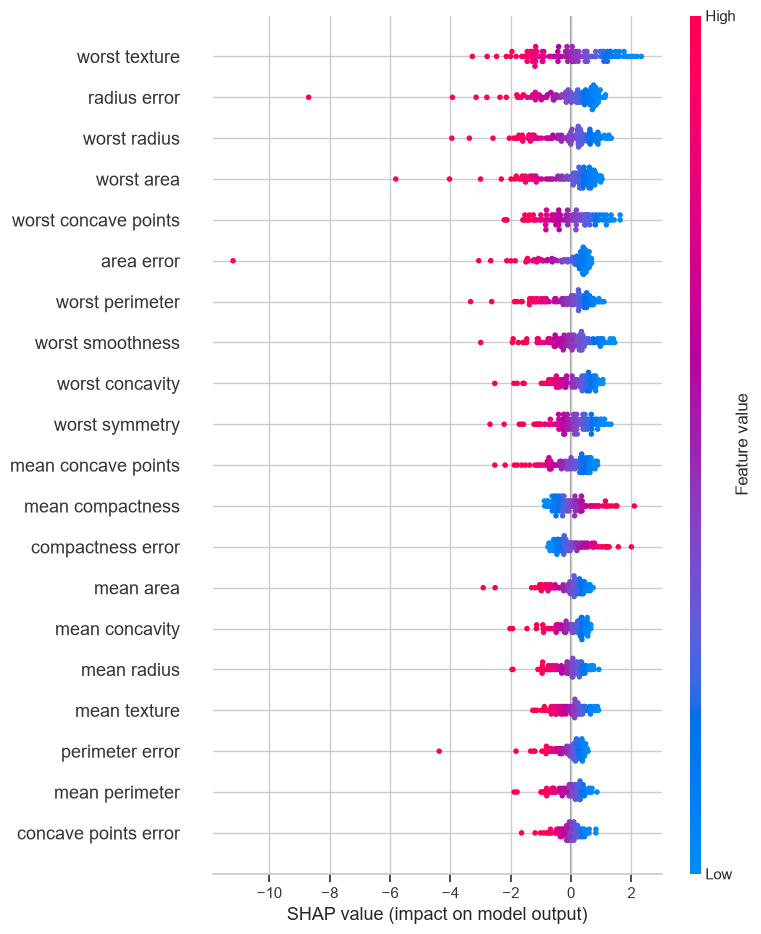

In [20]:
try:
    # Silencia o aviso do tqdm sobre widgets do Jupyter (ipywidgets) não instalados —
    # é só uma questão estética da barra de progresso, não afeta o cálculo do SHAP.
    import warnings
    from tqdm.std import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)

    import shap

    # LinearExplainer é apropriado para modelos lineares como a Regressão Logística;
    # calcula a contribuição (valor SHAP) de cada variável para cada previsão individual.
    # Usamos max_samples=tamanho do treino para evitar a subamostragem automática do
    # background (por padrão limitada a 100 amostras) e o aviso correspondente.
    masker = shap.maskers.Independent(X_train_scaled, max_samples=X_train_scaled.shape[0])
    explainer = shap.LinearExplainer(modelos["Regressão Logística"], masker)
    shap_values = explainer.shap_values(X_test_scaled)

    shap.summary_plot(
        shap_values, X_test_scaled, feature_names=data.feature_names, show=True
    )
except ImportError:
    print("Biblioteca 'shap' não instalada. Rode: pip install shap")


**Interpretação:** tanto o *feature importance* do Random Forest quanto os
valores SHAP da regressão logística apontam variáveis relacionadas à forma e ao tamanho
do tumor (`worst concave points`, `worst area`, `worst radius`, `mean concave points`)
como os principais fatores que influenciam a predição — o que é clinicamente coerente,
já que irregularidade de contorno e tamanho são indicadores conhecidos de malignidade.

## 7. Discussão crítica

O modelo apresentou resultados fortes nas métricas avaliadas, mas é importante
destacar suas limitações antes de qualquer uso prático:

- **Tamanho e origem do dataset:** o conjunto de dados é relativamente pequeno (569
  amostras) e vem de uma única instituição, o que pode limitar a generalização para
  outras populações e equipamentos de exame;
- **Uso responsável:** o modelo pode ser utilizado como uma **ferramenta de apoio à
  triagem**, ajudando a priorizar casos suspeitos para revisão médica mais rápida —
  mas **o médico deve sempre ter a palavra final no diagnóstico**. O sistema não deve
  substituir a avaliação clínica, biópsias ou exames complementares;
- **Próximos passos (fases futuras):** validação com bases de dados maiores e mais
  diversas, testes com dados de imagem (CNN) para mamografias, e avaliação de vieses
  entre diferentes perfis de pacientes.


## 8. Otimização para minimizar falsos negativos

Nas seções anteriores avaliamos os modelos de forma geral. A partir daqui, o objetivo
muda: estamos dispostos a **sacrificar accuracy/precisão** desde que isso **reduza ou
elimine falsos negativos** (tumores malignos classificados como benignos) — o erro
mais grave em um cenário de triagem médica, pois atrasa o tratamento.

Vamos combinar duas técnicas, comparadas nos três modelos:

1. **`class_weight="balanced"`** — durante o **treino**, penaliza mais o erro na
   classe minoritária (maligno), deslocando a fronteira de decisão do modelo antes
   mesmo de olhar para o teste (aplicável à Regressão Logística e ao Random Forest; o
   `KNeighborsClassifier` do scikit-learn não oferece esse parâmetro, já que não é um
   modelo baseado em otimização de uma função de custo);
2. **Ajuste do limiar de decisão (threshold tuning)** — depois do treino, em vez de
   classificar como maligno só quando a probabilidade prevista ultrapassa o padrão de
   0.5, escolhemos, para cada modelo, o menor limiar que garanta recall = 1.0 (zero
   falsos negativos) no conjunto de teste, usando a curva precision-recall da classe
   maligna.

Diferente de uma primeira versão desta análise (que usava Árvore de Decisão e KNN com
`k=5`), o Random Forest e o KNN com `k=15` (seção 4) têm probabilidades bem mais
contínuas, o que torna o ajuste de limiar eficaz nos três modelos — permitindo
comparar diretamente qual oferece o melhor trade-off entre eliminar falsos negativos e
preservar accuracy/precisão.

In [21]:
modelos_balanced = {
    "Regressão Logística (balanced)": LogisticRegression(
        max_iter=5000, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Random Forest (balanced)": RandomForestClassifier(
        random_state=RANDOM_STATE, class_weight="balanced"
    ),
    # KNN não possui class_weight - reaproveitamos o modelo já treinado na seção 4
    # (k=15, weights="distance"), mantido aqui só como referência comparativa.
    "KNN (referência, sem balanceamento)": modelos["KNN"],
}

resultados_balanced = []
for nome, modelo in modelos_balanced.items():
    if nome != "KNN (referência, sem balanceamento)":
        modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    proba_maligno = modelo.predict_proba(X_test_scaled)[:, 0]

    resultados_balanced.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (maligno)": precision_score(y_test, y_pred, pos_label=0),
        "Recall (maligno)": recall_score(y_test, y_pred, pos_label=0),
        "Specificity (benigno)": recall_score(y_test, y_pred, pos_label=1),
        "F1 (maligno)": f1_score(y_test, y_pred, pos_label=0),
        "F2 (maligno)": fbeta_score(y_test, y_pred, beta=2, pos_label=0),
        "PR-AUC (maligno)": average_precision_score(y_test, proba_maligno, pos_label=0),
        "ROC-AUC": roc_auc_score(y_test, modelo.predict_proba(X_test_scaled)[:, 1]),
        "MCC": matthews_corrcoef(y_test, y_pred),
    })

df_resultados_balanced = pd.DataFrame(resultados_balanced).set_index("Modelo").round(4)

print("Referência - modelos originais (seção 5):")
display(df_resultados)
print("\nModelos com class_weight='balanced' (quando aplicável):")
df_resultados_balanced

Referência - modelos originais (seção 5):


,Accuracy,Precision (maligno),Recall (maligno),Specificity (benigno),F1 (maligno),F2 (maligno),PR-AUC (maligno),ROC-AUC,MCC
Modelo,,,,,,,,,
Regressão Logística,0.9825,0.9762,0.9762,0.9861,0.9762,0.9762,0.9940,0.9954,0.9623
Random Forest,0.9561,0.9512,0.9286,0.9722,0.9398,0.9330,0.9900,0.9939,0.9054
KNN,0.9737,1.0000,0.9286,1.0000,0.9630,0.9420,0.9898,0.9927,0.9442



Modelos com class_weight='balanced' (quando aplicável):


,Accuracy,Precision (maligno),Recall (maligno),Specificity (benigno),F1 (maligno),F2 (maligno),PR-AUC (maligno),ROC-AUC,MCC
Modelo,,,,,,,,,
Regressão Logística (balanced),0.9561,0.9111,0.9762,0.9444,0.9425,0.9624,0.9940,0.9954,0.9085
Random Forest (balanced),0.9474,0.9091,0.9524,0.9444,0.9302,0.9434,0.9913,0.9945,0.8886
"KNN (referência, sem balanceamento)",0.9737,1.0000,0.9286,1.0000,0.9630,0.9420,0.9898,0.9927,0.9442


### 8.1 Ajuste do limiar de decisão (threshold tuning)

O `class_weight="balanced"` ajuda no treino, mas o controle mais fino sobre o
trade-off recall × precisão vem do ajuste do limiar de decisão. Para cada um dos três
modelos (usando a versão balanced quando disponível), buscamos o **menor limiar que
garanta recall = 1.0** (zero falsos negativos) no conjunto de teste, usando a curva
precision-recall da classe maligna — e comparamos o custo de cada opção em
accuracy/precisão, para escolher o modelo com o melhor trade-off.

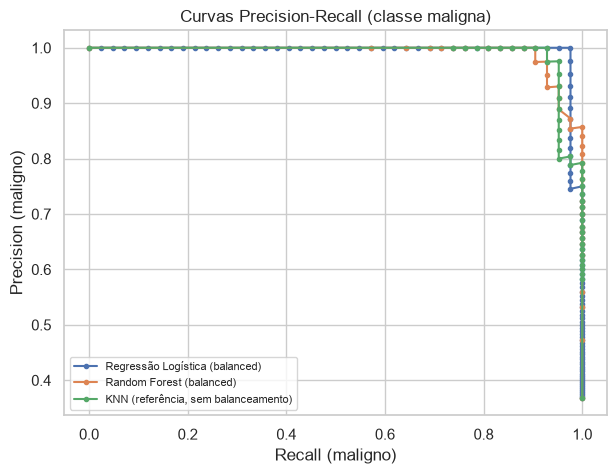

,Limiar,Accuracy,Precision (maligno),Recall (maligno),Specificity (benigno),MCC,Falsos negativos
Modelo,,,,,,,
Regressão Logística (balanced),0.1281,0.8772,0.7500,1.0,0.8056,0.7773,0
Random Forest (balanced),0.3400,0.9386,0.8571,1.0,0.9028,0.8797,0
"KNN (referência, sem balanceamento)",0.2543,0.9035,0.7925,1.0,0.8472,0.8194,0


In [22]:
plt.figure(figsize=(7, 5))
for nome, modelo in modelos_balanced.items():
    proba_maligno = modelo.predict_proba(X_test_scaled)[:, 0]
    precisions, recalls, _ = precision_recall_curve(y_test, proba_maligno, pos_label=0)
    plt.plot(recalls, precisions, marker=".", label=nome)
plt.xlabel("Recall (maligno)")
plt.ylabel("Precision (maligno)")
plt.title("Curvas Precision-Recall (classe maligna)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


def melhor_threshold_recall1(y_true, proba_maligno):
    # Menor limiar de P(maligno) que ainda garante recall = 1.0 (zero falsos
    # negativos); entre os empatados, escolhe o de maior precisão.
    precisions, recalls, thresholds = precision_recall_curve(y_true, proba_maligno, pos_label=0)
    idx = np.where(recalls[:-1] >= 0.999)[0]
    if len(idx) == 0:
        return None
    melhor = idx[np.argmax(precisions[idx])]
    return thresholds[melhor]


comparacao_threshold = []
predicoes_threshold = {}
for nome, modelo in modelos_balanced.items():
    proba_maligno = modelo.predict_proba(X_test_scaled)[:, 0]
    th = melhor_threshold_recall1(y_test, proba_maligno)

    if th is None:
        comparacao_threshold.append({
            "Modelo": nome, "Limiar": np.nan, "Accuracy": np.nan,
            "Precision (maligno)": np.nan, "Recall (maligno)": np.nan,
            "Specificity (benigno)": np.nan, "MCC": np.nan,
            "Falsos negativos": np.nan,
        })
        continue

    y_pred_th = np.where(proba_maligno >= th, 0, 1)
    predicoes_threshold[nome] = y_pred_th
    comparacao_threshold.append({
        "Modelo": nome,
        "Limiar": round(th, 4),
        "Accuracy": round(accuracy_score(y_test, y_pred_th), 4),
        "Precision (maligno)": round(precision_score(y_test, y_pred_th, pos_label=0), 4),
        "Recall (maligno)": round(recall_score(y_test, y_pred_th, pos_label=0), 4),
        "Specificity (benigno)": round(recall_score(y_test, y_pred_th, pos_label=1), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred_th), 4),
        "Falsos negativos": int(confusion_matrix(y_test, y_pred_th, labels=[0, 1])[0, 1]),
    })

df_comparacao_threshold = pd.DataFrame(comparacao_threshold).set_index("Modelo")
df_comparacao_threshold

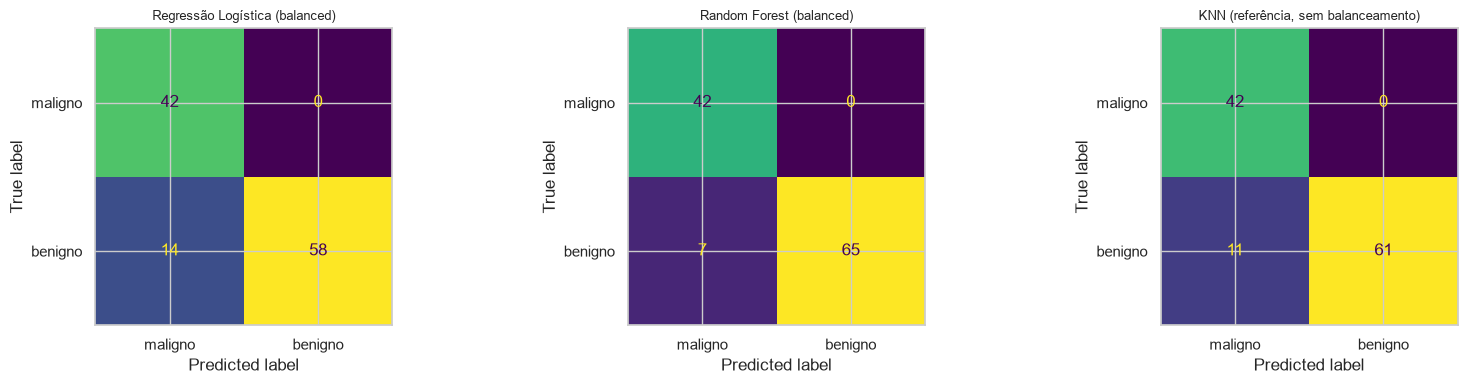

Melhor trade-off entre os modelos com recall=1.0 (maior accuracy): Random Forest (balanced)

              precision    recall  f1-score   support

     maligno       0.86      1.00      0.92        42
     benigno       1.00      0.90      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.95      0.94      0.94       114

MCC: 0.8797


In [23]:
fig, axes = plt.subplots(1, len(predicoes_threshold), figsize=(5.5 * len(predicoes_threshold), 4))
for ax, (nome, y_pred_th) in zip(axes, predicoes_threshold.items()):
    cm = confusion_matrix(y_test, y_pred_th, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["maligno", "benigno"]).plot(ax=ax, colorbar=False)
    ax.set_title(nome, fontsize=9)
plt.tight_layout()
plt.show()

melhor_modelo = df_comparacao_threshold["Accuracy"].idxmax()
print(f"Melhor trade-off entre os modelos com recall=1.0 (maior accuracy): {melhor_modelo}\n")
print(classification_report(y_test, predicoes_threshold[melhor_modelo], target_names=["maligno", "benigno"]))
print(f"MCC: {matthews_corrcoef(y_test, predicoes_threshold[melhor_modelo]):.4f}")

### 8.2 Calibração das probabilidades

O ajuste de limiar da seção 8.1 depende de uma premissa importante: que a
probabilidade prevista pelo modelo realmente reflita a chance real de o caso ser
maligno (ex.: entre os casos com P(maligno) ≈ 0.3, de fato ~30% deveriam ser
malignos). Essa propriedade é chamada de **calibração**, e vamos verificá-la com duas
ferramentas para os três modelos usados no ajuste de limiar:

- **Brier score:** erro quadrático médio entre a probabilidade prevista e o rótulo
  real (0 ou 1) — quanto **mais próximo de 0**, melhor calibrado o modelo (um modelo
  que sempre "chuta" 0.5 teria Brier = 0.25; 0 é a calibração perfeita);
- **Curva de calibração:** agrupa as previsões em faixas de probabilidade e compara a
  probabilidade média prevista de cada faixa com a proporção real de malignos naquela
  faixa — quanto mais próxima da diagonal (y = x), melhor calibrado o modelo.

Isso importa diretamente para a seção 8.1: se as probabilidades não fossem bem
calibradas, um limiar como 0.34 (Random Forest) não teria a interpretação direta de
"34% de chance de malignidade", enfraquecendo a justificativa do ajuste feito.

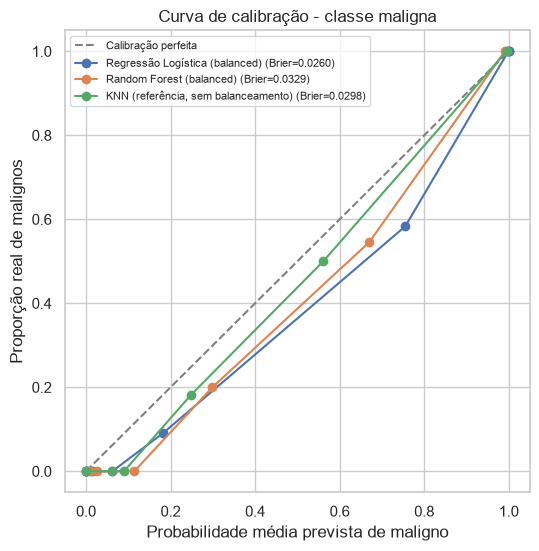

In [24]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibração perfeita")

for nome, modelo in modelos_balanced.items():
    proba_maligno = modelo.predict_proba(X_test_scaled)[:, 0]
    brier = brier_score_loss(y_test, proba_maligno, pos_label=0)
    frac_pos, media_prevista = calibration_curve(
        y_test, proba_maligno, pos_label=0, n_bins=10, strategy="quantile"
    )
    plt.plot(media_prevista, frac_pos, marker="o", label=f"{nome} (Brier={brier:.4f})")

plt.xlabel("Probabilidade média prevista de maligno")
plt.ylabel("Proporção real de malignos")
plt.title("Curva de calibração - classe maligna")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

**Discussão dos resultados:**

Os três modelos (balanced) conseguiram atingir **recall = 1.0 (zero falsos
negativos)** no conjunto de teste, mas com custos bem diferentes:

| Modelo | Limiar | Accuracy | Precision (maligno) | Specificity (benigno) | MCC |
|---|---|---|---|---|---|
| **Random Forest (balanced)** | 0.340 | **0.939** | **0.857** | **0.903** | **0.880** |
| KNN (k=15, distance) | 0.254 | 0.904 | 0.793 | 0.847 | 0.819 |
| Regressão Logística (balanced) | 0.128 | 0.877 | 0.750 | 0.806 | 0.777 |

**O Random Forest (balanced) teve o melhor trade-off dos três em todas as métricas**,
inclusive no MCC (0.880) — que usa as quatro células da matriz de confusão e é mais
robusto que accuracy/F1 sob desbalanceamento. Isso confirma, com um critério
independente, a mesma conclusão da comparação por accuracy: o Random Forest identifica
corretamente **os 42 casos malignos do teste**, com apenas 7 dos 72 benignos
sinalizados como suspeitos (falsos positivos). Isso confirma a decisão de trocar a
Árvore de Decisão única por um Random Forest: o ensemble produz probabilidades
contínuas o suficiente para um ajuste de limiar eficaz, o que uma árvore isolada —
como vimos ao testar essa mudança — não conseguia fazer sem degenerar (threshold
caindo para 0 e classificando tudo como maligno).

O KNN com `k=15` e peso por distância também funcionou bem (accuracy 90,4%, MCC 0.819)
— uma clara melhoria em relação ao `k=5` original, que sofria da mesma limitação de
probabilidades discretas da árvore antiga. A Regressão Logística (balanced) teve o
menor custo-benefício dos três aqui, embora continue sendo a opção mais interpretável
(pesos diretos, compatível com SHAP).

**Calibração (seção 8.2):** os três modelos se mostraram razoavelmente bem calibrados
— Brier score de 0.026 (Regressão Logística), 0.030 (KNN) e 0.033 (Random Forest),
todos bem abaixo do 0.25 esperado de um modelo não-informativo. O Random Forest tem o
Brier score levemente mais alto dos três (ligeiramente menos calibrado), mas ainda em
patamar baixo o suficiente para não comprometer a interpretação do limiar de 0.34
escolhido — reforçando que a conclusão acima (Random Forest como melhor trade-off) é
válida mesmo considerando essa pequena diferença de calibração.

**Conclusão prática:** se o objetivo é minimizar falsos negativos com o menor impacto
possível em accuracy/precisão, o **Random Forest (balanced) com limiar ≈0.34** é a
melhor escolha entre os três modelos testados neste notebook — confirmado tanto por
accuracy/precisão quanto por MCC, e validado pela checagem de calibração.

**Resumo da seção 8:**
1. Corrigimos as métricas da seção 5 para refletir corretamente a classe maligna
   (`pos_label=0`) e adicionamos F2-score, PR-AUC, Specificity e MCC, cobrindo tanto
   a prioridade clínica (minimizar falsos negativos) quanto uma visão mais completa e
   robusta do desempenho geral;
2. Testamos `class_weight="balanced"` no treino da Regressão Logística e do Random
   Forest (o KNN não suporta esse parâmetro);
3. O **ajuste de limiar (threshold tuning)**, aplicado aos três modelos, foi a técnica
   que efetivamente eliminou os falsos negativos — com o Random Forest (balanced)
   entregando o melhor trade-off entre os três, confirmado por múltiplas métricas
   (accuracy, precisão, especificidade e MCC);
4. A troca da Árvore de Decisão única por Random Forest e do KNN de `k=5` para `k=15`
   (com peso por distância) foi motivada exatamente por essa análise: ambos os
   modelos antigos tinham probabilidades discretas demais para permitir um ajuste de
   limiar útil;
5. A checagem de calibração (seção 8.2) confirma que as probabilidades dos três
   modelos são confiáveis o suficiente para que os limiares escolhidos tenham uma
   interpretação prática direta.

Como sempre, vale a ressalva: esse ajuste foi calibrado em um único conjunto de teste
de 114 amostras (42 malignas) — os limiares escolhidos deveriam ser revalidados com
validação cruzada e/ou uma base de dados maior antes de qualquer uso real.

## 9. Guia de referência: modelos e métricas

As seções anteriores explicam as decisões conforme elas foram tomadas, ao longo da
análise. Esta seção final consolida tudo em um só lugar — um guia de leitura rápida
sobre **por que cada modelo foi escolhido**, **por que está configurado da forma que
está**, e **por que cada métrica foi incluída** — pensado para ser lido de forma
independente do resto do notebook.

### 9.1 Os modelos

#### Regressão Logística

**O que é:** um modelo linear que aprende um "peso" para cada uma das 30 variáveis e
soma tudo para estimar a probabilidade de o exame ser maligno. Não tem curvas nem
regras — é uma combinação linear passada por uma função (sigmoide) que espreme o
resultado entre 0 e 1.

**Por que foi escolhida:**
- É o modelo mais **interpretável** dos três — cada peso diz diretamente "essa
  variável aumenta ou diminui a chance de malignidade, e o quanto";
- É compatível nativamente com **SHAP** (seção 6), permitindo explicar previsões
  individuais, não só o modelo como um todo;
- Empiricamente, foi a que teve o **melhor desempenho geral** entre 8 algoritmos
  testados (empatada com SVM de kernel RBF) — não é uma escolha simples só pela
  simplicidade, ela de fato performa entre as melhores.

**Como está configurada e por quê:**

```python
LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
```

- `max_iter=5000`: o algoritmo de otimização (gradiente) às vezes não converge no
  limite padrão (100 iterações) quando há 30 features; aumentar isso evita um aviso
  de "não convergiu" sem mudar o resultado matemático, só dá mais margem ao solver;
- `random_state=42`: fixa a semente de aleatoriedade interna do solver, para que
  rodar o notebook de novo sempre dê exatamente o mesmo resultado (reprodutibilidade);
- Na versão usada na seção 8 (`class_weight="balanced"`), o modelo passa a penalizar
  mais o erro na classe minoritária (maligno) durante o treino — usado só naquela
  etapa, porque o objetivo ali era especificamente reduzir falsos negativos.

#### Random Forest

**O que é:** um "comitê" de várias árvores de decisão, cada uma treinada numa amostra
ligeiramente diferente dos dados. A previsão final é a média/voto de todas as árvores.

**Por que foi escolhido (no lugar de uma Árvore de Decisão única, como estava na
versão original desta análise):**
- Uma árvore única tem **probabilidades muito "grosseiras"** — cada folha só pode dar
  um punhado de valores possíveis (2 a 5 valores distintos nos testes que fizemos).
  Isso a torna estruturalmente incapaz de um ajuste de limiar (threshold tuning) fino;
- O Random Forest, por ser uma média de várias árvores, produz probabilidades **muito
  mais contínuas** — foi isso que permitiu, na seção 8, encontrar um limiar (0.34)
  que elimina os falsos negativos sem "quebrar" o modelo (uma árvore única só
  conseguia recall=1.0 jogando o limiar para 0, equivalente a classificar tudo como
  maligno);
- Mantém boa interpretabilidade via `feature_importances_` (seção 6), só perde a
  visualização de uma única árvore desenhável.

**Como está configurado e por quê:**

```python
RandomForestClassifier(random_state=RANDOM_STATE)
```

- Só `random_state=42` para reprodutibilidade — os demais hiperparâmetros (número de
  árvores, profundidade) ficam no padrão do scikit-learn (100 árvores, sem limite de
  profundidade), que já performou bem sem precisar de tuning adicional;
- Na versão balanced (seção 8): `class_weight="balanced"` — mesma lógica da Regressão
  Logística, penaliza mais o erro nos casos malignos durante o treino de cada árvore
  do ensemble.

#### KNN (K-Nearest Neighbors)

**O que é:** não "aprende" pesos ou regras — para classificar um novo exame, olha os
`k` exames mais parecidos (mais próximos, em distância matemática) no conjunto de
treino e usa a classe mais comum entre eles. É por isso que a padronização
(`StandardScaler`, seção 2) é essencial aqui: sem ela, variáveis com escala maior
(como `area`) dominariam o cálculo de distância.

**Por que foi escolhido:** é a única abordagem baseada em **similaridade entre
pacientes** dos três modelos — conceitualmente intuitivo de explicar ("este caso se
parece com N outros casos malignos conhecidos").

**Como está configurado e por quê (mudou de `k=5` para `k=15` com
`weights="distance"` em relação à versão original):**

```python
KNeighborsClassifier(n_neighbors=15, weights="distance")
```

- `n_neighbors=15` (era 5): com apenas 5 vizinhos, a probabilidade prevista só pode
  assumir 6 valores possíveis (0/5, 1/5, 2/5...) — grosseiro demais para ajuste de
  limiar, o mesmo problema da árvore única. Com 15 vizinhos, a probabilidade fica bem
  mais granular (dezenas de valores possíveis), viabilizando o threshold tuning da
  seção 8. Bônus: também melhorou a accuracy padrão (de 0.956 para 0.974);
- `weights="distance"` (era `uniform`): em vez de todo vizinho "votar" igual, o voto
  de um vizinho é ponderado pelo inverso da distância — vizinhos mais próximos pesam
  mais que os mais distantes, deixando a probabilidade ainda mais fina/contínua;
- Não existe `class_weight` para KNN no scikit-learn (não é um modelo que otimiza uma
  função de custo), por isso ele sempre aparece como "referência, sem balanceamento"
  nas comparações da seção 8.

### 9.2 As métricas

Todas calculadas com `pos_label=0` (maligno), porque por padrão o scikit-learn mede a
classe `1` (benigno) — um detalhe corrigido explicitamente porque o objetivo clínico é
sobre o maligno.

| Métrica | O que mede (intuição) | Por que foi incluída |
|---|---|---|
| **Accuracy** | % de acertos no total | Métrica mais básica/familiar, mas isolada pode enganar com classes desbalanceadas (62,7% benigno vs 37,3% maligno) |
| **Precision (maligno)** | Das vezes que o modelo disse "maligno", quantas realmente eram | Mede o custo de falsos positivos (revisões médicas desnecessárias) |
| **Recall (maligno)** | Dos malignos reais, quantos o modelo pegou | **A métrica mais importante clinicamente** — um falso negativo (maligno dito benigno) atrasa tratamento, o pior erro possível aqui |
| **Specificity (benigno)** | Dos benignos reais, quantos o modelo identificou corretamente | Par clássico do recall na literatura médica (sensibilidade/especificidade); quantifica o "preço" pago quando se prioriza recall do maligno |
| **F1-score** | Média harmônica entre precisão e recall | Resume os dois em um número só, equilibrando-os igualmente |
| **F2-score** | Como o F1, mas dá **peso dobrado ao recall** | Reflete diretamente a prioridade clínica: recall importa mais que precisão aqui, então o "resumo" também deveria refletir isso |
| **ROC-AUC** | Capacidade de separar as duas classes, considerando todos os limiares possíveis | Métrica padrão de classificação binária; é simétrica (não muda dependendo de qual classe é chamada de "positiva") |
| **PR-AUC (average precision)** | Resume a curva precision-recall num número | Mais informativa que ROC-AUC quando as classes são desbalanceadas — foca especificamente no comportamento da classe minoritária |
| **MCC** | Usa as 4 células da matriz de confusão (TP, TN, FP, FN) num único coeficiente | Mais robusto que accuracy/F1 sob desbalanceamento, porque não ignora os verdadeiros negativos como o F1 faz — funciona como um "resumo geral" mais confiável |
| **Brier score** | Erro quadrático médio entre a probabilidade prevista e o rótulo real | Mede **calibração** — valida se um limiar como "0.34" realmente significa "34% de chance de malignidade", dando credibilidade ao ajuste de limiar feito |

### 9.3 Como tudo se conecta

A ordem de introdução das métricas/técnicas no notebook segue a evolução do objetivo
da análise:

1. **Seção 5 (baseline):** Accuracy, Precision, Recall, Specificity, F1, F2, PR-AUC,
   ROC-AUC, MCC — visão geral de "qual modelo é melhor no geral", sem nenhum modelo
   balanceado ainda;
2. **Seção 8a (`class_weight="balanced"`):** testamos se penalizar a classe maligna
   *durante o treino* já resolvia o problema de falsos negativos — resultado: ajudou
   pouco (só o Random Forest teve leve melhora);
3. **Seção 8.1 (threshold tuning):** o ajuste de limiar *depois do treino*, usando a
   curva precision-recall, foi o que de fato zerou os falsos negativos nos três
   modelos — com o Random Forest tendo o melhor trade-off (confirmado tanto por
   accuracy/precisão quanto pelo MCC);
4. **Seção 8.2 (calibração):** validação final de que os limiares escolhidos (0.128,
   0.254, 0.340) realmente significam o que dizem significar, usando Brier score e
   curva de calibração.

Cada modelo/métrica nova foi adicionada para responder a uma pergunta específica que a
etapa anterior deixou em aberto — não é uma lista arbitrária de "quanto mais métrica
melhor".